In [1]:
import numpy as np
import scipy as sp
# import jax.numpy as jnp
import matplotlib.pyplot as plt
import healpy as hp
import camb
import os

In [2]:
root_dir = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01'
obsmat_SAT4_f030_coadd = 'sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz'
ivar_f030_coadd = 'sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits'


167653
134.99388015045713 64.125


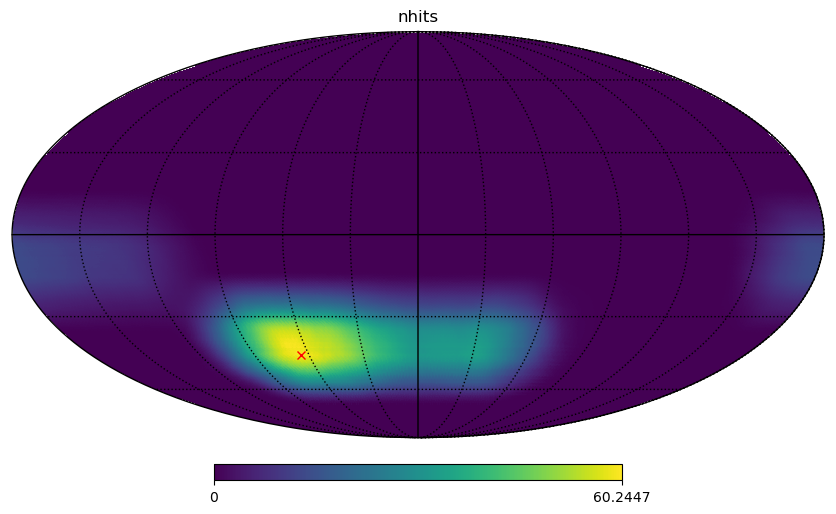

137497
2.356087678668095 1.1191923828413637


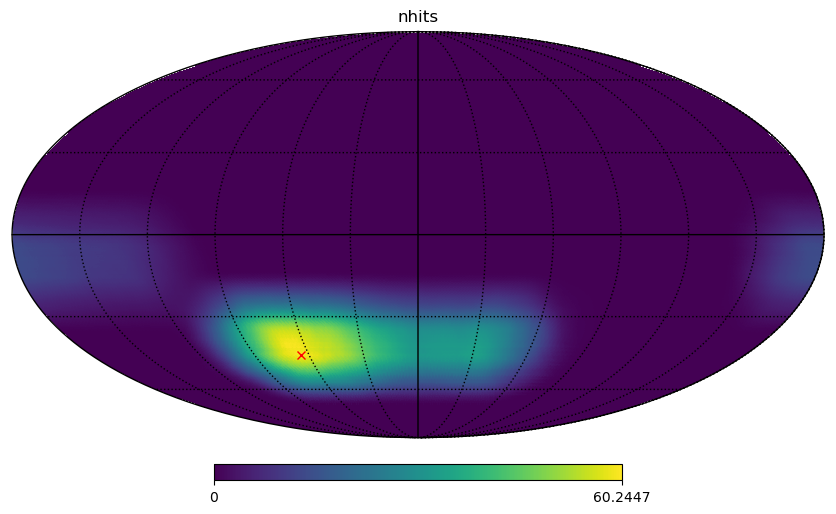

In [3]:
# Getting the index of the pixels with highes nhits:
nhits = hp.read_map(os.path.join( root_dir, ivar_f030_coadd), field=None)
index_max_pix_Q = np.argmax(nhits[1])

# Checking position of the pixel with highest nhits:
nside = hp.get_nside(nhits)
#  getting position of the pixel with highest nhits:
theta, phi = hp.pix2ang(nside, index_max_pix_Q)
print(index_max_pix_Q)
print(np.degrees(theta), np.degrees(phi))

#  plotting the pixel with highest nhits:
hp.mollview(nhits[1], title='nhits')
hp.projplot(theta, phi, 'rx')
hp.graticule()
plt.show()

#  Get index in NESTED ordering:  
index_max_pix_Q_nest = hp.ring2nest(nside, index_max_pix_Q)
print(index_max_pix_Q_nest)
theta_nest, phi_nest = hp.pix2ang(nside, index_max_pix_Q_nest, nest=True)
print(theta_nest, phi_nest)
# Converting nhits to NESTED ordering:
nhits_nest = hp.reorder(nhits, r2n=True)

hp.mollview(nhits_nest[1], title='nhits', nest=True)
hp.projplot(theta_nest, phi_nest, 'rx')
hp.graticule()
plt.show()



In [4]:
column_index_max_pix_Q = hp.nside2npix(nside) + index_max_pix_Q_nest #  index of the Q pixel in the column of the obs matrix
print(column_index_max_pix_Q)

334105


In [5]:
%%time
path_observation_matrix = os.path.join(root_dir, obsmat_SAT4_f030_coadd)
print(path_observation_matrix)
obs_matrix_sparse = sp.sparse.load_npz(path_observation_matrix)

/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz
CPU times: user 1min 5s, sys: 10.2 s, total: 1min 15s
Wall time: 1min 16s


In [6]:
max_pix_map = obs_matrix_sparse.getcol(column_index_max_pix_Q)

In [7]:
max_pix_map_Q = max_pix_map.toarray().flatten()[hp.nside2npix(nside):2*hp.nside2npix(nside)]

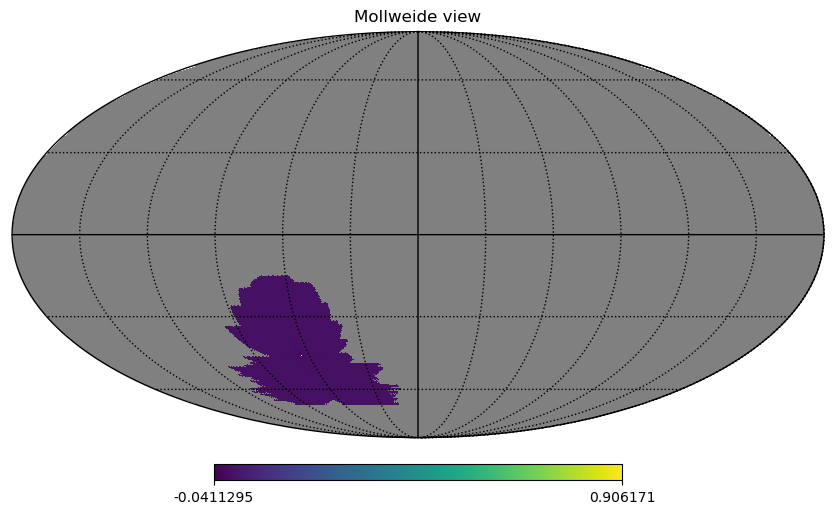

<function matplotlib.pyplot.show(close=None, block=None)>

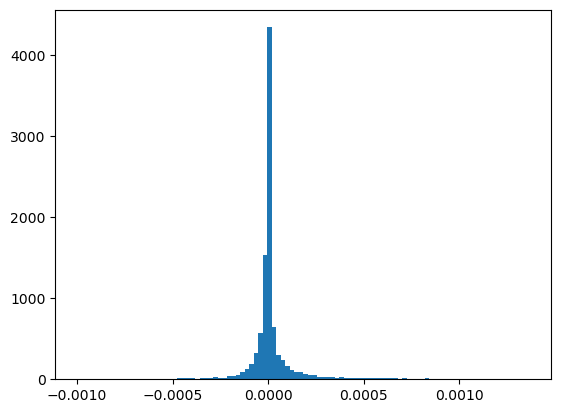

In [21]:
max_pix_map_Q[np.where(max_pix_map_Q == 0)] = hp.UNSEEN
hp.mollview(max_pix_map_Q, nest=True)
hp.graticule()
plt.show()

non_zero_max_pix_map_Q = max_pix_map_Q[(max_pix_map_Q != hp.UNSEEN) & (max_pix_map_Q <= 0.2) & (-0.001<= max_pix_map_Q)]
plt.hist(non_zero_max_pix_map_Q, bins=100)
plt.show

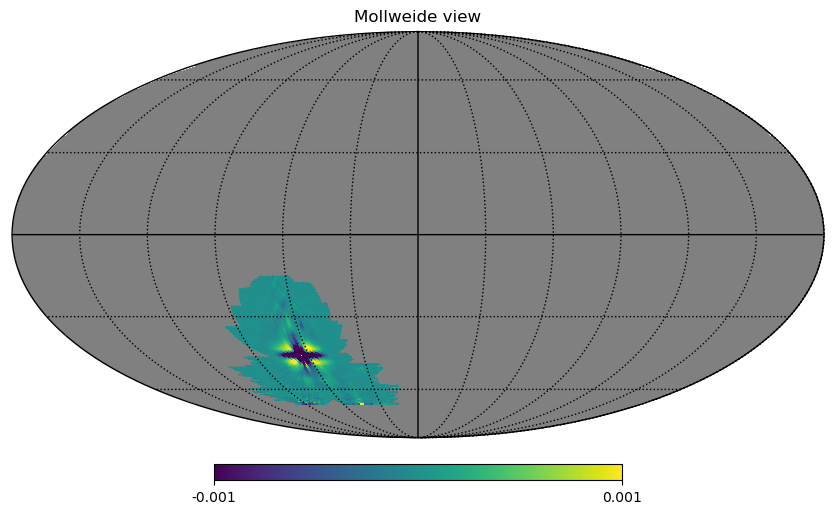

In [22]:
hp.mollview(max_pix_map_Q, nest=True, min=-1e-3, max=1e-3)
hp.graticule()
plt.show()

In [37]:
th_cl = np.load('/global/homes/j/jost/Megatop/unlensed_scalar_cls.npy')
th_cl_reorder = np.array([th_cl[0,0].tolist(), th_cl[1,1].tolist(), th_cl[2,2].tolist(), th_cl[0,1].tolist()]) # TT, EE, BB, TE
test_maps = hp.synfast(th_cl_reorder, nside, new=True)

In [44]:
max_pix_map_Q


array([0., 0., 0., ..., 0., 0., 0.])

In [42]:
np.all(test_maps_unravel[hp.nside2npix(nside):2*hp.nside2npix(nside)] == test_maps[1])

True